In [2]:
!pip install xgboost


Testing different models

In [3]:
# Import libraries
import os
import pandas as pd
import numpy as np
from google.cloud import storage
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
import xgboost as xgb

# Set up Google Cloud credentials
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = '/content/peppy-web-437616-r6-ec3f12e7c15e.json'

# Function to download file from GCS
def download_blob(bucket_name, source_blob_name, destination_file_name):
    storage_client = storage.Client()
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(source_blob_name)
    blob.download_to_filename(destination_file_name)
    print(f"Downloaded {source_blob_name} to {destination_file_name}")

# Download the data from GCS
bucket_name = 'ycbs299'
blob_name = 'master_merged_adjusted_updated.csv'
local_file = '/content/master_merged_adjusted_updated.csv'
download_blob(bucket_name, blob_name, local_file)

# Load the data
df = pd.read_csv(local_file).dropna()

# Define features
features = ['MONTH_SIN', 'MONTH_COS', 'LAG1_INCIDENT_COUNT', 'TEMPERATURE_MAX',
            'CRIME_COUNT', 'TOTAL_BUILDING_AREA', 'TOTAL_BUILDINGS',
            'RESIDENTIAL', 'PUBLIC_SERVICES', 'AVG_FLOORS']
X = df[features]

# Setup for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# --- 1. XGBoost Classification (RISK_LEVEL) ---
print("\n=== XGBoost Classification (RISK_LEVEL) ===")
le = LabelEncoder()
y_class = le.fit_transform(df['UPDATED_RISK_LEVEL'])

# Define parameter grid
xgb_clf_param_grid = {
    'max_depth': [3, 6],
    'learning_rate': [0.1, 0.01],
    'n_estimators': [100, 200]
}

xgb_clf_base = xgb.XGBClassifier(objective='multi:softmax', num_class=3, eval_metric='mlogloss', random_state=42)
xgb_clf = GridSearchCV(xgb_clf_base, xgb_clf_param_grid, cv=kf, scoring='accuracy', n_jobs=-1)
xgb_clf.fit(X, y_class)

print(f"Best Parameters: {xgb_clf.best_params_}")
print(f"Best Cross-Validated Accuracy: {xgb_clf.best_score_:.3f}")

# Detailed CV results
cv_results = pd.DataFrame(xgb_clf.cv_results_)
print("CV Results (mean_test_score):", cv_results['mean_test_score'].tolist())

# Feature importance (from best model)
print("Feature Importance:")
for feature, importance in zip(features, xgb_clf.best_estimator_.feature_importances_):
    print(f"{feature}: {importance:.4f}")

# --- 2. XGBoost Regression (INCIDENT_COUNT) ---
print("\n=== XGBoost Regression (INCIDENT_COUNT) ===")
y_reg = df['INCIDENT_COUNT']

# Define parameter grid
xgb_reg_param_grid = {
    'max_depth': [3, 6],
    'learning_rate': [0.1, 0.01],
    'n_estimators': [100, 200]
}

xgb_reg_base = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_reg = GridSearchCV(xgb_reg_base, xgb_reg_param_grid, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
xgb_reg.fit(X, y_reg)

print(f"Best Parameters: {xgb_reg.best_params_}")
print(f"Best Cross-Validated MSE: {-xgb_reg.best_score_:.3f}")  # Negated because scoring is negative MSE

# R² from cross-validation (manual calculation)
cv_preds = np.zeros(len(y_reg))
for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_reg.iloc[train_idx], y_reg.iloc[test_idx]
    xgb_reg.best_estimator_.fit(X_train, y_train)
    cv_preds[test_idx] = xgb_reg.best_estimator_.predict(X_test)
r2 = r2_score(y_reg, cv_preds)
print(f"Cross-Validated R²: {r2:.3f}")

print("Feature Importance:")
for feature, importance in zip(features, xgb_reg.best_estimator_.feature_importances_):
    print(f"{feature}: {importance:.4f}")

# --- 3. Random Forest Classification (RISK_LEVEL) ---
print("\n=== Random Forest Classification (RISK_LEVEL) ===")
y_class = le.fit_transform(df['RISK_LEVEL'])

# Define parameter grid
rf_clf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf_clf_base = RandomForestClassifier(random_state=42)
rf_clf = GridSearchCV(rf_clf_base, rf_clf_param_grid, cv=kf, scoring='accuracy', n_jobs=-1)
rf_clf.fit(X, y_class)

print(f"Best Parameters: {rf_clf.best_params_}")
print(f"Best Cross-Validated Accuracy: {rf_clf.best_score_:.3f}")

cv_results = pd.DataFrame(rf_clf.cv_results_)
print("CV Results (mean_test_score):", cv_results['mean_test_score'].tolist())

print("Feature Importance:")
for feature, importance in zip(features, rf_clf.best_estimator_.feature_importances_):
    print(f"{feature}: {importance:.4f}")

# --- 4. Random Forest Regression (INCIDENT_COUNT) ---
print("\n=== Random Forest Regression (INCIDENT_COUNT) ===")
y_reg = df['INCIDENT_COUNT']

# Define parameter grid
rf_reg_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf_reg_base = RandomForestRegressor(random_state=42)
rf_reg = GridSearchCV(rf_reg_base, rf_reg_param_grid, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
rf_reg.fit(X, y_reg)

print(f"Best Parameters: {rf_reg.best_params_}")
print(f"Best Cross-Validated MSE: {-rf_reg.best_score_:.3f}")

# R² from cross-validation
cv_preds = np.zeros(len(y_reg))
for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_reg.iloc[train_idx], y_reg.iloc[test_idx]
    rf_reg.best_estimator_.fit(X_train, y_train)
    cv_preds[test_idx] = rf_reg.best_estimator_.predict(X_test)
r2 = r2_score(y_reg, cv_preds)
print(f"Cross-Validated R²: {r2:.3f}")

print("Feature Importance:")
for feature, importance in zip(features, rf_reg.best_estimator_.feature_importances_):
    print(f"{feature}: {importance:.4f}")

Downloaded master_merged_adjusted_updated.csv to /content/master_merged_adjusted_updated.csv

=== XGBoost Classification (RISK_LEVEL) ===
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best Cross-Validated Accuracy: 0.686
CV Results (mean_test_score): [0.6818813430383474, 0.686382517307532, 0.6858757877451922, 0.6808040904966098, 0.6569668380754647, 0.6626089779084643, 0.6742107775501036, 0.6770003024861142]
Feature Importance:
MONTH_SIN: 0.0540
MONTH_COS: 0.1449
LAG1_INCIDENT_COUNT: 0.3307
TEMPERATURE_MAX: 0.0634
CRIME_COUNT: 0.2218
TOTAL_BUILDING_AREA: 0.0207
TOTAL_BUILDINGS: 0.0286
RESIDENTIAL: 0.0416
PUBLIC_SERVICES: 0.0725
AVG_FLOORS: 0.0218

=== XGBoost Regression (INCIDENT_COUNT) ===
Best Parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}
Best Cross-Validated MSE: 9.777
Cross-Validated R²: 0.595
Feature Importance:
MONTH_SIN: 0.0650
MONTH_COS: 0.1470
LAG1_INCIDENT_COUNT: 0.3274
TEMPERATURE_MAX: 0.0561
CRIME_COUNT: 0.1860
TOTAL_B

In [5]:
# Install required packages
!pip install xgboost

# Import libraries
import os
import pandas as pd
import numpy as np
from google.cloud import storage
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
import xgboost as xgb

# Set up Google Cloud credentials
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = '/content/peppy-web-437616-r6-ec3f12e7c15e.json'

# Function to download file from GCS
def download_blob(bucket_name, source_blob_name, destination_file_name):
    storage_client = storage.Client()
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(source_blob_name)
    blob.download_to_filename(destination_file_name)
    print(f"Downloaded {source_blob_name} to {destination_file_name}")

# Download the data from GCS
bucket_name = 'ycbs299'
blob_name = 'master_merged_adjusted_updated.csv'
local_file = '/content/master_merged_adjusted_updated.csv'
download_blob(bucket_name, blob_name, local_file)

# Load the data
df = pd.read_csv(local_file).dropna()

# Define features
features = ['MONTH_SIN', 'MONTH_COS', 'LAG1_INCIDENT_COUNT', 'TEMPERATURE_MAX',
            'CRIME_COUNT', 'TOTAL_BUILDING_AREA', 'TOTAL_BUILDINGS',
            'RESIDENTIAL', 'PUBLIC_SERVICES', 'AVG_FLOORS']
X = df[features]

# Setup for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# --- 1. XGBoost Classification (RISK_LEVEL) ---
print("\n=== XGBoost Classification (RISK_LEVEL) ===")
le = LabelEncoder()
y_class = le.fit_transform(df['UPDATED_RISK_LEVEL'])

# Define parameter grid
xgb_clf_param_grid = {
    'max_depth': [3, 6],
    'learning_rate': [0.1, 0.01],
    'n_estimators': [100, 200]
}

xgb_clf_base = xgb.XGBClassifier(objective='multi:softmax', num_class=3, eval_metric='mlogloss', random_state=42)
xgb_clf = GridSearchCV(xgb_clf_base, xgb_clf_param_grid, cv=kf, scoring='accuracy', n_jobs=-1)
xgb_clf.fit(X, y_class)

print(f"Best Parameters: {xgb_clf.best_params_}")
print(f"Best Cross-Validated Accuracy: {xgb_clf.best_score_:.3f}")

# Detailed CV results
cv_results = pd.DataFrame(xgb_clf.cv_results_)
print("CV Results (mean_test_score):", cv_results['mean_test_score'].tolist())

# Feature importance (from best model)
print("Feature Importance:")
for feature, importance in zip(features, xgb_clf.best_estimator_.feature_importances_):
    print(f"{feature}: {importance:.4f}")

# --- 2. XGBoost Regression (INCIDENT_COUNT) ---
print("\n=== XGBoost Regression (INCIDENT_COUNT) ===")
y_reg = df['INCIDENT_COUNT']

# Define parameter grid
xgb_reg_param_grid = {
    'max_depth': [3, 6],
    'learning_rate': [0.1, 0.01],
    'n_estimators': [100, 200]
}

xgb_reg_base = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_reg = GridSearchCV(xgb_reg_base, xgb_reg_param_grid, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
xgb_reg.fit(X, y_reg)

print(f"Best Parameters: {xgb_reg.best_params_}")
print(f"Best Cross-Validated MSE: {-xgb_reg.best_score_:.3f}")  # Negated because scoring is negative MSE

# R² from cross-validation (manual calculation)
cv_preds = np.zeros(len(y_reg))
for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_reg.iloc[train_idx], y_reg.iloc[test_idx]
    xgb_reg.best_estimator_.fit(X_train, y_train)
    cv_preds[test_idx] = xgb_reg.best_estimator_.predict(X_test)
r2 = r2_score(y_reg, cv_preds)
print(f"Cross-Validated R²: {r2:.3f}")

print("Feature Importance:")
for feature, importance in zip(features, xgb_reg.best_estimator_.feature_importances_):
    print(f"{feature}: {importance:.4f}")

# --- 3. Random Forest Classification (RISK_LEVEL) ---
print("\n=== Random Forest Classification (RISK_LEVEL) ===")
y_class = le.fit_transform(df['RISK_LEVEL'])

# Define parameter grid
rf_clf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf_clf_base = RandomForestClassifier(random_state=42)
rf_clf = GridSearchCV(rf_clf_base, rf_clf_param_grid, cv=kf, scoring='accuracy', n_jobs=-1)
rf_clf.fit(X, y_class)

print(f"Best Parameters: {rf_clf.best_params_}")
print(f"Best Cross-Validated Accuracy: {rf_clf.best_score_:.3f}")

cv_results = pd.DataFrame(rf_clf.cv_results_)
print("CV Results (mean_test_score):", cv_results['mean_test_score'].tolist())

print("Feature Importance:")
for feature, importance in zip(features, rf_clf.best_estimator_.feature_importances_):
    print(f"{feature}: {importance:.4f}")

# --- 4. Random Forest Regression (INCIDENT_COUNT) ---
print("\n=== Random Forest Regression (INCIDENT_COUNT) ===")
y_reg = df['INCIDENT_COUNT']

# Define parameter grid
rf_reg_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf_reg_base = RandomForestRegressor(random_state=42)
rf_reg = GridSearchCV(rf_reg_base, rf_reg_param_grid, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
rf_reg.fit(X, y_reg)

print(f"Best Parameters: {rf_reg.best_params_}")
print(f"Best Cross-Validated MSE: {-rf_reg.best_score_:.3f}")

# R² from cross-validation
cv_preds = np.zeros(len(y_reg))
for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_reg.iloc[train_idx], y_reg.iloc[test_idx]
    rf_reg.best_estimator_.fit(X_train, y_train)
    cv_preds[test_idx] = rf_reg.best_estimator_.predict(X_test)
r2 = r2_score(y_reg, cv_preds)
print(f"Cross-Validated R²: {r2:.3f}")

print("Feature Importance:")
for feature, importance in zip(features, rf_reg.best_estimator_.feature_importances_):
    print(f"{feature}: {importance:.4f}")

Downloaded master_merged_adjusted_updated.csv to /content/master_merged_adjusted_updated.csv

=== XGBoost Classification (RISK_LEVEL) ===
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best Cross-Validated Accuracy: 0.686
CV Results (mean_test_score): [0.6818813430383474, 0.686382517307532, 0.6858757877451922, 0.6808040904966098, 0.6569668380754647, 0.6626089779084643, 0.6742107775501036, 0.6770003024861142]
Feature Importance:
MONTH_SIN: 0.0540
MONTH_COS: 0.1449
LAG1_INCIDENT_COUNT: 0.3307
TEMPERATURE_MAX: 0.0634
CRIME_COUNT: 0.2218
TOTAL_BUILDING_AREA: 0.0207
TOTAL_BUILDINGS: 0.0286
RESIDENTIAL: 0.0416
PUBLIC_SERVICES: 0.0725
AVG_FLOORS: 0.0218

=== XGBoost Regression (INCIDENT_COUNT) ===
Best Parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}
Best Cross-Validated MSE: 9.777
Cross-Validated R²: 0.595
Feature Importance:
MONTH_SIN: 0.0650
MONTH_COS: 0.1470
LAG1_INCIDENT_COUNT: 0.3274
TEMPERATURE_MAX: 0.0561
CRIME_COUNT: 0.1860
TOTAL_B

In [3]:
# Install required packages
!pip install xgboost

# Import libraries
import os
import pandas as pd
import numpy as np
from google.cloud import storage
from sklearn.model_selection import KFold, GridSearchCV, train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

# Set up Google Cloud credentials
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = '/content/peppy-web-437616-r6-ec3f12e7c15e.json'

# Function to download file from GCS
def download_blob(bucket_name, source_blob_name, destination_file_name):
    storage_client = storage.Client()
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(source_blob_name)
    blob.download_to_filename(destination_file_name)
    print(f"Downloaded {source_blob_name} to {destination_file_name}")

# Function to upload file to GCS
def upload_blob(bucket_name, source_file_name, destination_blob_name):
    storage_client = storage.Client()
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(destination_blob_name)
    blob.upload_from_filename(source_file_name)
    print(f"Uploaded {source_file_name} to {destination_blob_name}")

# Download the data from GCS
bucket_name = 'ycbs299'
blob_name = 'master_merged_adjusted_updated.csv'
local_file = '/content/master_merged_adjusted_updated.csv'
download_blob(bucket_name, blob_name, local_file)

# Load and process data
df = pd.read_csv(local_file).dropna()
df['DATE'] = pd.to_datetime(df[['YEAR', 'MONTH']].assign(DAY=1))
df = df.sort_values(['CASERNE', 'DATE'])

# Define features (your specified list)
features = ['MONTH_SIN', 'MONTH_COS', 'LAG1_INCIDENT_COUNT', 'TEMPERATURE_MAX',
            'CRIME_COUNT', 'TOTAL_BUILDING_AREA', 'TOTAL_BUILDINGS',
            'RESIDENTIAL', 'PUBLIC_SERVICES', 'AVG_FLOORS']
X = df[features]

# XGBoost Classification with Cross-Validation and GridSearchCV
print("\n=== XGBoost Classification (RISK_LEVEL) ===")
le = LabelEncoder()
y_class = le.fit_transform(df['UPDATED_RISK_LEVEL'])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
xgb_clf_param_grid = {
    'max_depth': [3, 6],
    'learning_rate': [0.1, 0.01],
    'n_estimators': [100, 200]
}
xgb_clf_base = xgb.XGBClassifier(objective='multi:softmax', num_class=3, eval_metric='mlogloss', random_state=42)
xgb_clf = GridSearchCV(xgb_clf_base, xgb_clf_param_grid, cv=kf, scoring='accuracy', n_jobs=-1)
xgb_clf.fit(X, y_class)

print(f"Best Parameters: {xgb_clf.best_params_}")
print(f"Best Cross-Validated Accuracy: {xgb_clf.best_score_:.3f}")
print("CV Results (mean_test_score):", pd.DataFrame(xgb_clf.cv_results_)['mean_test_score'].tolist())

print("Feature Importance:")
for feature, importance in zip(features, xgb_clf.best_estimator_.feature_importances_):
    print(f"{feature}: {importance:.4f}")

# Evaluate on a single split for detailed metrics
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.4, random_state=42)
xgb_clf.best_estimator_.fit(X_train, y_train)
y_pred = xgb_clf.best_estimator_.predict(X_test)
y_pred_proba = xgb_clf.best_estimator_.predict_proba(X_test)

print("Classification Report (Single Split):")
print(classification_report(y_test, y_pred, target_names=le.classes_))
auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
print(f"AUC-ROC (One-vs-Rest): {auc:.3f}")

# Add predictions to the full dataset
df['PREDICTED_RISK'] = le.inverse_transform(xgb_clf.best_estimator_.predict(X))
df['PREDICTED_RISK_PROBA'] = xgb_clf.best_estimator_.predict_proba(X).max(axis=1)

# Save and upload predictions
output_file = '/content/fire_risk_predictions.csv'
df.to_csv(output_file, index=False)
print(f"Saved predictions to {output_file}")
upload_blob(bucket_name, output_file, 'fire_risk_predictions.csv')

Downloaded master_merged_adjusted_updated.csv to /content/master_merged_adjusted_updated.csv

=== XGBoost Classification (RISK_LEVEL) ===
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best Cross-Validated Accuracy: 0.686
CV Results (mean_test_score): [0.6818813430383474, 0.686382517307532, 0.6858757877451922, 0.6808040904966098, 0.6569668380754647, 0.6626089779084643, 0.6742107775501036, 0.6770003024861142]
Feature Importance:
MONTH_SIN: 0.0540
MONTH_COS: 0.1449
LAG1_INCIDENT_COUNT: 0.3307
TEMPERATURE_MAX: 0.0634
CRIME_COUNT: 0.2218
TOTAL_BUILDING_AREA: 0.0207
TOTAL_BUILDINGS: 0.0286
RESIDENTIAL: 0.0416
PUBLIC_SERVICES: 0.0725
AVG_FLOORS: 0.0218
Classification Report (Single Split):
              precision    recall  f1-score   support

        High       0.62      0.61      0.62      1198
         Low       0.77      0.86      0.81      3510
      Medium       0.44      0.34      0.38      1602

    accuracy                           0.68      6310
   ma

In [1]:
# Install required packages
!pip install xgboost

# Import libraries
import os
import pandas as pd
import numpy as np
from google.cloud import storage
from sklearn.model_selection import KFold, GridSearchCV, train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

# Set up Google Cloud credentials
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = '/content/peppy-web-437616-r6-ec3f12e7c15e.json'

# Function to download file from GCS
def download_blob(bucket_name, source_blob_name, destination_file_name):
    storage_client = storage.Client()
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(source_blob_name)
    blob.download_to_filename(destination_file_name)
    print(f"Downloaded {source_blob_name} to {destination_file_name}")

# Function to upload file to GCS
def upload_blob(bucket_name, source_file_name, destination_blob_name):
    storage_client = storage.Client()
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(destination_blob_name)
    blob.upload_from_filename(source_file_name)
    print(f"Uploaded {source_file_name} to {destination_blob_name}")

# Download the data from GCS
bucket_name = 'ycbs299'
blob_name = 'master_merged_adjusted_updated.csv'
local_file = '/content/master_merged_adjusted_updated.csv'
download_blob(bucket_name, blob_name, local_file)

# Load and process data
df = pd.read_csv(local_file).dropna()
df['DATE'] = pd.to_datetime(df[['YEAR', 'MONTH']].assign(DAY=1))
df = df.sort_values(['CASERNE', 'DATE'])

# Define features (your original 10)
features = ['MONTH_SIN', 'MONTH_COS', 'LAG1_INCIDENT_COUNT', 'TEMPERATURE_MAX',
            'CRIME_COUNT', 'TOTAL_BUILDING_AREA', 'TOTAL_BUILDINGS',
            'RESIDENTIAL', 'PUBLIC_SERVICES', 'AVG_FLOORS']
X = df[features]

# XGBoost Classification with Cross-Validation and GridSearchCV
print("\n=== XGBoost Classification (UPDATED_RISK_LEVEL) ===")
le = LabelEncoder()
y_class = le.fit_transform(df['UPDATED_RISK_LEVEL'])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
xgb_clf_param_grid = {
    'max_depth': [3, 6],
    'learning_rate': [0.1, 0.01],
    'n_estimators': [100, 200]
}
xgb_clf_base = xgb.XGBClassifier(objective='multi:softmax', num_class=3, eval_metric='mlogloss', random_state=42)
xgb_clf = GridSearchCV(xgb_clf_base, xgb_clf_param_grid, cv=kf, scoring='accuracy', n_jobs=-1)
xgb_clf.fit(X, y_class)

print(f"Best Parameters: {xgb_clf.best_params_}")
print(f"Best Cross-Validated Accuracy: {xgb_clf.best_score_:.3f}")
print("CV Results (mean_test_score):", pd.DataFrame(xgb_clf.cv_results_)['mean_test_score'].tolist())

print("Feature Importance:")
for feature, importance in zip(features, xgb_clf.best_estimator_.feature_importances_):
    print(f"{feature}: {importance:.4f}")

# Evaluate on a 20% random split for detailed metrics
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=42)
xgb_clf.best_estimator_.fit(X_train, y_train)
y_pred = xgb_clf.best_estimator_.predict(X_test)
y_pred_proba = xgb_clf.best_estimator_.predict_proba(X_test)

print("Classification Report (20% Random Split):")
print(classification_report(y_test, y_pred, target_names=le.classes_))
auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
print(f"AUC-ROC (One-vs-Rest): {auc:.3f}")

# Add predictions to the full dataset
df['PREDICTED_RISK'] = le.inverse_transform(xgb_clf.best_estimator_.predict(X))
df['PREDICTED_RISK_PROBA'] = xgb_clf.best_estimator_.predict_proba(X).max(axis=1)

# Save and upload predictions
output_file = '/content/fire_risk_predictions.csv'
df.to_csv(output_file, index=False)
print(f"Saved predictions to {output_file}")
upload_blob(bucket_name, output_file, 'fire_risk_predictions.csv')

Downloaded master_merged_adjusted_updated.csv to /content/master_merged_adjusted_updated.csv

=== XGBoost Classification (UPDATED_RISK_LEVEL) ===
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best Cross-Validated Accuracy: 0.686
CV Results (mean_test_score): [0.6818813430383474, 0.686382517307532, 0.6858757877451922, 0.6808040904966098, 0.6569668380754647, 0.6626089779084643, 0.6742107775501036, 0.6770003024861142]
Feature Importance:
MONTH_SIN: 0.0540
MONTH_COS: 0.1449
LAG1_INCIDENT_COUNT: 0.3307
TEMPERATURE_MAX: 0.0634
CRIME_COUNT: 0.2218
TOTAL_BUILDING_AREA: 0.0207
TOTAL_BUILDINGS: 0.0286
RESIDENTIAL: 0.0416
PUBLIC_SERVICES: 0.0725
AVG_FLOORS: 0.0218
Classification Report (20% Random Split):
              precision    recall  f1-score   support

        High       0.64      0.59      0.61       585
         Low       0.76      0.87      0.81      1756
      Medium       0.45      0.32      0.37       814

    accuracy                           0.68    

visal predictions monthly  and gif

In [9]:
# Install required packages
!pip install xgboost geopandas folium matplotlib imageio selenium
!apt-get update
!apt-get install -y chromium-chromedriver
!cp /usr/lib/chromium-browser/chromedriver /usr/bin

# Import libraries
import os
import pandas as pd
import numpy as np
from google.cloud import storage
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import geopandas as gpd
import folium
import imageio.v2 as imageio
from datetime import datetime, timedelta
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
import time

# Set up Google Cloud credentials
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = '/content/peppy-web-437616-r6-ec3f12e7c15e.json'

# Function to download file from GCS
def download_blob(bucket_name, source_blob_name, destination_file_name):
    storage_client = storage.Client()
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(source_blob_name)
    blob.download_to_filename(destination_file_name)
    print(f"Downloaded {source_blob_name} to {destination_file_name}")

# Function to upload file to GCS
def upload_blob(bucket_name, source_file_name, destination_blob_name):
    storage_client = storage.Client()
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(destination_blob_name)
    blob.upload_from_filename(source_file_name)
    print(f"Uploaded {source_file_name} to {destination_blob_name}")

# Download the data and GeoJSON from GCS
bucket_name = 'ycbs299'
data_blob_name = 'master_merged_adjusted_updated.csv'
geojson_blob_name = 'territoires-administratifs-casernes.geojson'
local_data_file = '/content/master_merged_adjusted_updated.csv'
local_geojson_file = '/content/territoires-administratifs-casernes.geojson'
download_blob(bucket_name, data_blob_name, local_data_file)
download_blob(bucket_name, geojson_blob_name, local_geojson_file)

# Load historical data
df = pd.read_csv(local_data_file).dropna()
df['DATE'] = pd.to_datetime(df[['YEAR', 'MONTH']].assign(DAY=1))
df = df.sort_values(['CASERNE', 'DATE'])

# Define features
features = ['MONTH_SIN', 'MONTH_COS', 'LAG1_INCIDENT_COUNT', 'TEMPERATURE_MAX',
            'CRIME_COUNT', 'TOTAL_BUILDING_AREA', 'TOTAL_BUILDINGS',
            'RESIDENTIAL', 'PUBLIC_SERVICES', 'AVG_FLOORS']
X = df[features]
y_class = df['UPDATED_RISK_LEVEL']

# Train XGBoost Classifier on full historical data
le = LabelEncoder()
y_class_encoded = le.fit_transform(y_class)
xgb_clf = xgb.XGBClassifier(objective='multi:softmax', num_class=3, eval_metric='mlogloss',
                            max_depth=3, learning_rate=0.1, n_estimators=200, random_state=42)
xgb_clf.fit(X, y_class_encoded)

# Generate future data (April 2025 – April 2026)
future_dates = pd.date_range(start='2025-04-01', end='2026-04-01', freq='MS')
casernes = df['CASERNE'].unique()
future_df = pd.DataFrame([(caserne, date.year, date.month) for caserne in casernes for date in future_dates],
                         columns=['CASERNE', 'YEAR', 'MONTH'])
future_df['DATE'] = pd.to_datetime(future_df[['YEAR', 'MONTH']].assign(DAY=1))

# Populate features for future data
future_df['MONTH_SIN'] = np.sin(2 * np.pi * future_df['MONTH'] / 12)
future_df['MONTH_COS'] = np.cos(2 * np.pi * future_df['MONTH'] / 12)
latest_df = df.groupby('CASERNE').last().reset_index()
for feature in ['TOTAL_BUILDING_AREA', 'TOTAL_BUILDINGS', 'RESIDENTIAL', 'PUBLIC_SERVICES', 'AVG_FLOORS']:
    future_df = future_df.merge(latest_df[['CASERNE', feature]], on='CASERNE', how='left')
for caserne in casernes:
    caserne_data = df[df['CASERNE'] == caserne]
    last_incident = caserne_data['INCIDENT_COUNT'].iloc[-1]
    avg_temp = caserne_data['TEMPERATURE_MAX'].mean()
    avg_crime = caserne_data['CRIME_COUNT'].mean()
    future_df.loc[future_df['CASERNE'] == caserne, 'LAG1_INCIDENT_COUNT'] = last_incident
    future_df.loc[future_df['CASERNE'] == caserne, 'TEMPERATURE_MAX'] = avg_temp
    future_df.loc[future_df['CASERNE'] == caserne, 'CRIME_COUNT'] = avg_crime

# Predict risk levels
X_future = future_df[features]
future_df['PREDICTED_RISK_ENCODED'] = xgb_clf.predict(X_future)
future_df['PREDICTED_RISK'] = le.inverse_transform(future_df['PREDICTED_RISK_ENCODED'])
future_df['PREDICTED_RISK_PROBA'] = xgb_clf.predict_proba(X_future).max(axis=1)

# Save predictions to CSV
output_file = '/content/fire_risk_predictions_2025_2026.csv'
future_df.to_csv(output_file, index=False)
print(f"Saved predictions to {output_file}")
upload_blob(bucket_name, output_file, 'fire_risk_predictions_2025_2026.csv')

# Load GeoJSON for mapping
gdf = gpd.read_file(local_geojson_file).to_crs("EPSG:4326")
gdf = gdf.rename(columns={"NO_CAS_ADM": "CASERNE"})

# Calculate the centroid of the GeoJSON to center the map
centroid = gdf.geometry.centroid
center_lat = centroid.y.mean()
center_lon = centroid.x.mean()

# Set up Selenium for PNG conversion
chrome_options = Options()
chrome_options.add_argument('--headless')
chrome_options.add_argument('--no-sandbox')
chrome_options.add_argument('--disable-dev-shm-usage')
driver = webdriver.Chrome(options=chrome_options)

# Generate PNG maps for each month
risk_colors = {'Low': '#00FF00', 'Medium': '#FFA500', 'High': '#FF0000'}  # Green, Orange, Red
png_files = []

for date in future_dates:
    month_df = future_df[future_df['DATE'] == date]
    map_gdf = gdf.merge(month_df[['CASERNE', 'PREDICTED_RISK']], on='CASERNE', how='left')
    map_gdf['color'] = map_gdf['PREDICTED_RISK'].map(risk_colors).fillna('#808080')

    # Create a folium map with dynamic centering
    m = folium.Map(location=[center_lat, center_lon], zoom_start=10, tiles='cartodbpositron')

    # Add GeoJSON layer
    folium.GeoJson(
        map_gdf,
        style_function=lambda feature: {
            'fillColor': feature['properties']['color'],
            'color': 'black',
            'weight': 1,
            'fillOpacity': 0.6
        }
    ).add_to(m)

    # Add title (month/year)
    month_str = date.strftime('%B %Y')
    title_html = f'<h3 align="center" style="font-size:16px"><b>Fire Risk Map - {month_str}</b></h3>'
    m.get_root().html.add_child(folium.Element(title_html))

    # Add legend (moved to bottom-right)
    legend_html = '''
    <div style="position: fixed; bottom: 50px; right: 50px; z-index: 1000; padding: 10px; background-color: white; border: 2px solid grey; border-radius: 5px;">
    <p><strong>Fire Risk Legend</strong></p>
    <p><span style="color: #FF0000;">■</span> High Risk</p>
    <p><span style="color: #FFA500;">■</span> Medium Risk</p>
    <p><span style="color: #00FF00;">■</span> Low Risk</p>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))

    # Save as HTML and convert to PNG
    month_str_file = date.strftime('%Y-%m')
    html_file = f'/content/risk_map_{month_str_file}.html'
    png_file = f'/content/risk_map_{month_str_file}.png'
    m.save(html_file)

    driver.get(f'file://{html_file}')
    time.sleep(2)
    driver.set_window_size(800, 600)
    driver.save_screenshot(png_file)

    if os.path.exists(png_file):
        png_files.append(png_file)
        print(f"Generated map for {month_str_file}: {png_file}")
    else:
        print(f"Failed to generate PNG for {month_str_file}")

# Close the driver
driver.quit()

# Create GIF from PNGs with slower duration and infinite loop
if png_files:
    images = [imageio.imread(png) for png in png_files]
    gif_file = '/content/fire_risk_evolution_2025_2026.gif'
    imageio.mimsave(gif_file, images, duration=10.0, loop=0)  # 10 seconds per frame, infinite loop
    print(f"Saved GIF to {gif_file}")
    upload_blob(bucket_name, gif_file, 'fire_risk_evolution_2025_2026.gif')
else:
    print("No PNG files generated; skipping GIF creation.")

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [3,000 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,535 kB]
Fetched 4,919 kB in 2s (2,353 kB/s)
Reading package lists... Done
W: Skipping acquire of

<ipython-input-9-e33c93227592>:110: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = gdf.geometry.centroid


Generated map for 2025-04: /content/risk_map_2025-04.png
Generated map for 2025-05: /content/risk_map_2025-05.png
Generated map for 2025-06: /content/risk_map_2025-06.png
Generated map for 2025-07: /content/risk_map_2025-07.png
Generated map for 2025-08: /content/risk_map_2025-08.png
Generated map for 2025-09: /content/risk_map_2025-09.png
Generated map for 2025-10: /content/risk_map_2025-10.png
Generated map for 2025-11: /content/risk_map_2025-11.png
Generated map for 2025-12: /content/risk_map_2025-12.png
Generated map for 2026-01: /content/risk_map_2026-01.png
Generated map for 2026-02: /content/risk_map_2026-02.png
Generated map for 2026-03: /content/risk_map_2026-03.png
Generated map for 2026-04: /content/risk_map_2026-04.png
Saved GIF to /content/fire_risk_evolution_2025_2026.gif
Uploaded /content/fire_risk_evolution_2025_2026.gif to fire_risk_evolution_2025_2026.gif


GENERATE GIF OF MONTHLY PREDICTIONS

In [10]:
from PIL import Image

frames = [Image.open(png) for png in png_files]
gif_file = "/content/fire_risk_evolution_2025_2026.gif"

frames[0].save(
    gif_file,
    format="GIF",
    append_images=frames[1:],
    save_all=True,
    duration=1000,  # 2000 milliseconds (2 seconds per frame)
    loop=0
)


In [11]:
# Install required packages
!pip install pandas matplotlib seaborn

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import storage
import os

# Set up Google Cloud credentials
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = '/content/peppy-web-437616-r6-ec3f12e7c15e.json'

# Function to download file from GCS
def download_blob(bucket_name, source_blob_name, destination_file_name):
    storage_client = storage.Client()
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(source_blob_name)
    blob.download_to_filename(destination_file_name)
    print(f"Downloaded {source_blob_name} to {destination_file_name}")

# Function to upload file to GCS
def upload_blob(bucket_name, source_file_name, destination_blob_name):
    storage_client = storage.Client()
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(destination_blob_name)
    blob.upload_from_filename(source_file_name)
    print(f"Uploaded {source_file_name} to {destination_blob_name}")

# Download the predictions CSV from GCS
bucket_name = 'ycbs299'
predictions_blob_name = 'fire_risk_predictions_2025_2026.csv'
local_predictions_file = '/content/fire_risk_predictions_2025_2026.csv'
download_blob(bucket_name, predictions_blob_name, local_predictions_file)

# Load the predictions
df = pd.read_csv(local_predictions_file)
df['DATE'] = pd.to_datetime(df['DATE'])

# Set up plotting style
sns.set(style="whitegrid")

# 1. High-Risk Casernes Over Time
# Filter for high-risk predictions
high_risk = df[df['PREDICTED_RISK'] == 'High']
high_risk_count = high_risk.groupby('CASERNE').size().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
high_risk_count.plot(kind='bar', color='red')
plt.title('Number of High-Risk Months per Caserne (April 2025 - April 2026)', fontsize=14)
plt.xlabel('Caserne', fontsize=12)
plt.ylabel('Number of High-Risk Months', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/content/high_risk_caserne_count.png')
plt.close()
upload_blob(bucket_name, '/content/high_risk_caserne_count.png', 'high_risk_caserne_count.png')

# 2. Risk Distribution by Month
# Create a column for month-year string
df['MONTH_YEAR'] = df['DATE'].dt.strftime('%Y-%m')

plt.figure(figsize=(14, 6))
risk_by_month = df.groupby(['MONTH_YEAR', 'PREDICTED_RISK']).size().unstack(fill_value=0)
risk_by_month.plot(kind='bar', stacked=True, color=['#00FF00', '#FFA500', '#FF0000'], ax=plt.gca())
plt.title('Risk Distribution by Month (April 2025 - April 2026)', fontsize=14)
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Number of Casernes', fontsize=12)
plt.legend(title='Risk Level', labels=['Low', 'Medium', 'High'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/content/risk_distribution_by_month.png')
plt.close()
upload_blob(bucket_name, '/content/risk_distribution_by_month.png', 'risk_distribution_by_month.png')

# 3. Feature Correlation with High Risk
# Create a binary column for high risk
df['IS_HIGH_RISK'] = (df['PREDICTED_RISK'] == 'High').astype(int)

# Select features to analyze
features_to_analyze = ['LAG1_INCIDENT_COUNT', 'TEMPERATURE_MAX', 'CRIME_COUNT', 'IS_HIGH_RISK']
correlation_matrix = df[features_to_analyze].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Between Features and High Risk', fontsize=14)
plt.tight_layout()
plt.savefig('/content/feature_correlation_high_risk.png')
plt.close()
upload_blob(bucket_name, '/content/feature_correlation_high_risk.png', 'feature_correlation_high_risk.png')

# 4. Confidence Scores for High-Risk Predictions
plt.figure(figsize=(10, 6))
sns.histplot(data=high_risk, x='PREDICTED_RISK_PROBA', bins=20, color='red', kde=True)
plt.title('Confidence Scores for High-Risk Predictions', fontsize=14)
plt.xlabel('Prediction Confidence (Probability)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.savefig('/content/high_risk_confidence_scores.png')
plt.close()
upload_blob(bucket_name, '/content/high_risk_confidence_scores.png', 'high_risk_confidence_scores.png')

Downloaded fire_risk_predictions_2025_2026.csv to /content/fire_risk_predictions_2025_2026.csv
Uploaded /content/high_risk_caserne_count.png to high_risk_caserne_count.png
Uploaded /content/risk_distribution_by_month.png to risk_distribution_by_month.png
Uploaded /content/feature_correlation_high_risk.png to feature_correlation_high_risk.png
Uploaded /content/high_risk_confidence_scores.png to high_risk_confidence_scores.png


Heuristic analysis

In [3]:
# Install required packages
!pip install xgboost pandas matplotlib seaborn scikit-learn

# Import libraries
import pandas as pd
import numpy as np
from google.cloud import storage
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

# Set up Google Cloud credentials
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = '/content/peppy-web-437616-r6-ec3f12e7c15e.json'

# Function to download file from GCS
def download_blob(bucket_name, source_blob_name, destination_file_name):
    storage_client = storage.Client()
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(source_blob_name)
    blob.download_to_filename(destination_file_name)
    print(f"Downloaded {source_blob_name} to {destination_file_name}")

# Function to upload file to GCS
def upload_blob(bucket_name, source_file_name, destination_blob_name):
    storage_client = storage.Client()
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(destination_blob_name)
    blob.upload_from_filename(source_file_name)
    print(f"Uploaded {source_file_name} to {destination_blob_name}")

# Download the historical data from GCS
bucket_name = 'ycbs299'
data_blob_name = 'master_merged_adjusted_updated.csv'
local_data_file = '/content/master_merged_adjusted_updated.csv'
download_blob(bucket_name, data_blob_name, local_data_file)

# Load historical data
df = pd.read_csv(local_data_file).dropna()
df['DATE'] = pd.to_datetime(df[['YEAR', 'MONTH']].assign(DAY=1))
df = df.sort_values(['CASERNE', 'DATE'])

# Define features for ML
features = ['MONTH_SIN', 'MONTH_COS', 'LAG1_INCIDENT_COUNT', 'TEMPERATURE_MAX',
            'CRIME_COUNT', 'TOTAL_BUILDING_AREA', 'TOTAL_BUILDINGS',
            'RESIDENTIAL', 'PUBLIC_SERVICES', 'AVG_FLOORS']
X = df[features]
y = df['UPDATED_RISK_LEVEL']

# Split data (20% random split as before)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Train XGBoost Classifier
xgb_clf = xgb.XGBClassifier(objective='multi:softmax', num_class=3, eval_metric='mlogloss',
                            max_depth=3, learning_rate=0.1, n_estimators=200, random_state=42)
xgb_clf.fit(X_train, y_train)

# ML predictions on test set
y_pred_ml = xgb_clf.predict(X_test)
y_pred_proba_ml = xgb_clf.predict_proba(X_test)

# Evaluate ML model
print("=== XGBoost Classification (RISK_LEVEL) ===")
print("Classification Report (ML Model):")
print(classification_report(y_test, y_pred_ml, target_names=le.classes_))
auc_ml = roc_auc_score(y_test, y_pred_proba_ml, multi_class='ovr')
print(f"AUC-ROC (One-vs-Rest, ML Model): {auc_ml:.3f}")

# Create Heuristic Baseline
# Step 1: Calculate historical mean INCIDENT_COUNT for each caserne-month
df['MONTH'] = df['DATE'].dt.month
historical_means = df.groupby(['CASERNE', 'MONTH'])['INCIDENT_COUNT'].mean().reset_index()
historical_means = historical_means.rename(columns={'INCIDENT_COUNT': 'MEAN_INCIDENT_COUNT'})

# Step 2: Define risk thresholds based on historical INCIDENT_COUNT
# Using quantiles: 50th and 80th percentiles (same as assign_risk_level)
incident_counts = df['INCIDENT_COUNT']
low_threshold = np.percentile(incident_counts, 50)  # Bottom 50% = Low
high_threshold = np.percentile(incident_counts, 80)  # 50% to 80% = Medium, >80% = High

print(f"\nHeuristic Thresholds:")
print(f"Low threshold (50th percentile): {low_threshold}")
print(f"High threshold (80th percentile): {high_threshold}")

def heuristic_risk(mean_count):
    if mean_count <= low_threshold:  # Bottom 50%
        return 'Low'
    elif mean_count <= high_threshold:  # 50% to 80%
        return 'Medium'
    else:  # Top 20%
        return 'High'

historical_means['HEURISTIC_RISK'] = historical_means['MEAN_INCIDENT_COUNT'].apply(heuristic_risk)

# Step 3: Apply heuristic to test set
test_df = X_test.copy()
test_df['MONTH'] = df.loc[X_test.index, 'MONTH'].values
test_df['CASERNE'] = df.loc[X_test.index, 'CASERNE'].values
test_df = test_df.merge(historical_means[['CASERNE', 'MONTH', 'HEURISTIC_RISK']], on=['CASERNE', 'MONTH'], how='left')

# If no historical data for a caserne-month, default to 'Low'
test_df['HEURISTIC_RISK'] = test_df['HEURISTIC_RISK'].fillna('Low')
y_pred_heuristic = le.transform(test_df['HEURISTIC_RISK'])

# Evaluate Heuristic
print("\n=== Heuristic Baseline (RISK_LEVEL) ===")
print("Classification Report (Heuristic):")
print(classification_report(y_test, y_pred_heuristic, target_names=le.classes_))

# For AUC-ROC, assign probabilities (simplified: 0.9 for predicted class, 0.05 for others)
y_pred_proba_heuristic = np.zeros((len(y_pred_heuristic), 3))
for i, label in enumerate(y_pred_heuristic):
    y_pred_proba_heuristic[i, label] = 0.9
    y_pred_proba_heuristic[i, y_pred_proba_heuristic[i] != 0.9] = 0.05
auc_heuristic = roc_auc_score(y_test, y_pred_proba_heuristic, multi_class='ovr')
print(f"AUC-ROC (One-vs-Rest, Heuristic): {auc_heuristic:.3f}")

# Visualize Comparison
metrics = pd.DataFrame({
    'Model': ['XGBoost', 'Heuristic'],
    'Accuracy': [
        classification_report(y_test, y_pred_ml, target_names=le.classes_, output_dict=True)['accuracy'],
        classification_report(y_test, y_pred_heuristic, target_names=le.classes_, output_dict=True)['accuracy']
    ],
    'AUC-ROC': [auc_ml, auc_heuristic]
})

plt.figure(figsize=(8, 6))
metrics_melted = metrics.melt(id_vars='Model', value_vars=['Accuracy', 'AUC-ROC'], var_name='Metric', value_name='Score')
sns.barplot(data=metrics_melted, x='Score', y='Model', hue='Metric')
plt.title('Performance Comparison: XGBoost vs. Heuristic Baseline', fontsize=14)
plt.xlabel('Score', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.tight_layout()
plt.savefig('/content/performance_comparison_updated.png')
plt.close()
upload_blob(bucket_name, '/content/performance_comparison_updated.png', 'performance_comparison_updated.png')

Downloaded master_merged_adjusted_updated.csv to /content/master_merged_adjusted_updated.csv
=== XGBoost Classification (RISK_LEVEL) ===
Classification Report (ML Model):
              precision    recall  f1-score   support

        High       0.64      0.59      0.61       585
         Low       0.76      0.87      0.81      1756
      Medium       0.45      0.32      0.37       814

    accuracy                           0.68      3155
   macro avg       0.61      0.60      0.60      3155
weighted avg       0.65      0.68      0.66      3155

AUC-ROC (One-vs-Rest, ML Model): 0.831

Heuristic Thresholds:
Low threshold (50th percentile): 5.0
High threshold (80th percentile): 9.0

=== Heuristic Baseline (RISK_LEVEL) ===
Classification Report (Heuristic):
              precision    recall  f1-score   support

        High       0.60      0.56      0.58       585
         Low       0.85      0.71      0.77      1756
      Medium       0.39      0.54      0.46       814

    accuracy     

Visual for confidence level

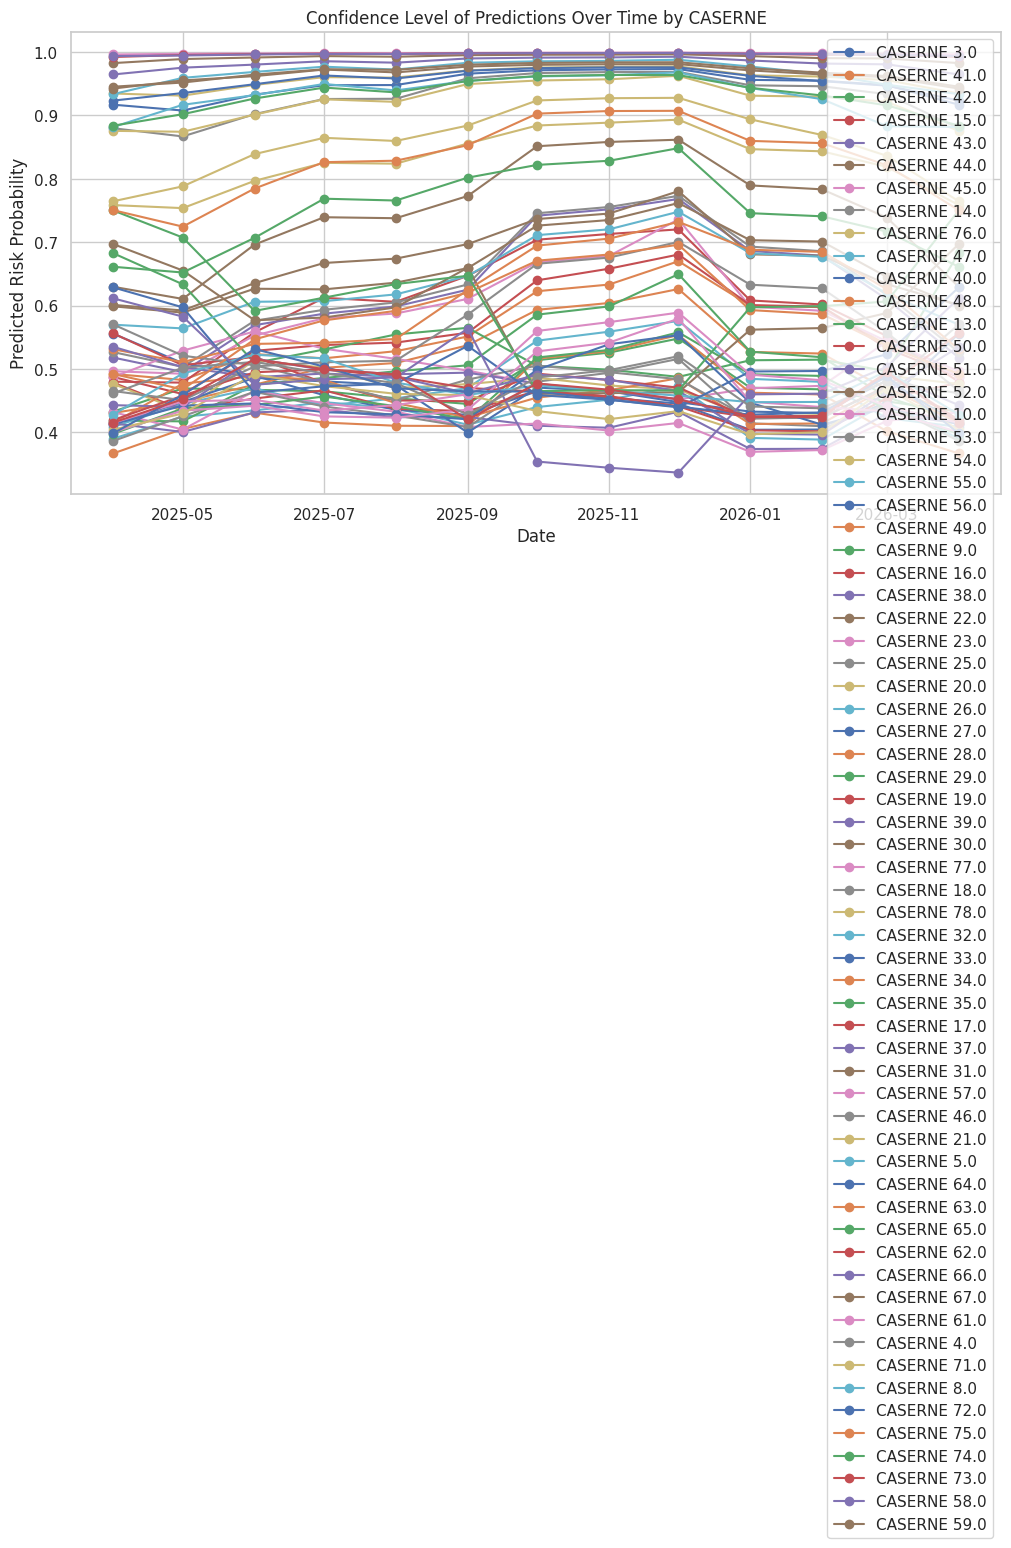

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data (assuming it's in a file named 'data.csv')
data = pd.read_csv('/content/fire_risk_predictions_2025_2026.csv')

# Convert DATE to datetime
data['DATE'] = pd.to_datetime(data['DATE'])

# Sort by date
data = data.sort_values('DATE')

# Plot
plt.figure(figsize=(12, 6))
for caserne in data['CASERNE'].unique():
    subset = data[data['CASERNE'] == caserne]
    plt.plot(subset['DATE'], subset['PREDICTED_RISK_PROBA'], label=f'CASERNE {caserne}', marker='o')

plt.xlabel('Date')
plt.ylabel('Predicted Risk Probability')
plt.title('Confidence Level of Predictions Over Time by CASERNE')
plt.legend()
plt.grid(True)
plt.show()

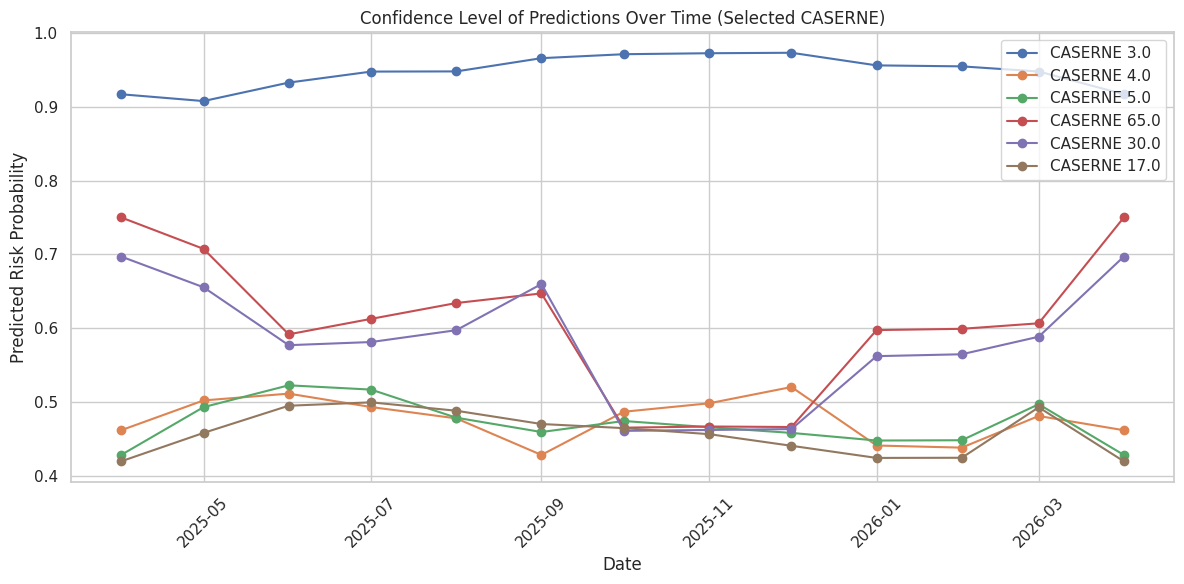

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data (assuming it's in a file named 'data.csv')
data = pd.read_csv('/content/fire_risk_predictions_2025_2026.csv')

# Convert DATE to datetime
data['DATE'] = pd.to_datetime(data['DATE'])

# Sort by date
data = data.sort_values('DATE')

# Select a subset of CASERNE values (e.g., 3.0, 4.0, 5.0)
selected_caserne = [3.0, 4.0, 5.0, 65.0, 30.0, 17.0]
subset_data = data[data['CASERNE'].isin(selected_caserne)]

# Plot
plt.figure(figsize=(12, 6))
for caserne in selected_caserne:
    caserne_data = subset_data[subset_data['CASERNE'] == caserne]
    plt.plot(caserne_data['DATE'], caserne_data['PREDICTED_RISK_PROBA'],
             label=f'CASERNE {caserne}', marker='o')

plt.xlabel('Date')
plt.ylabel('Predicted Risk Probability')
plt.title('Confidence Level of Predictions Over Time (Selected CASERNE)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

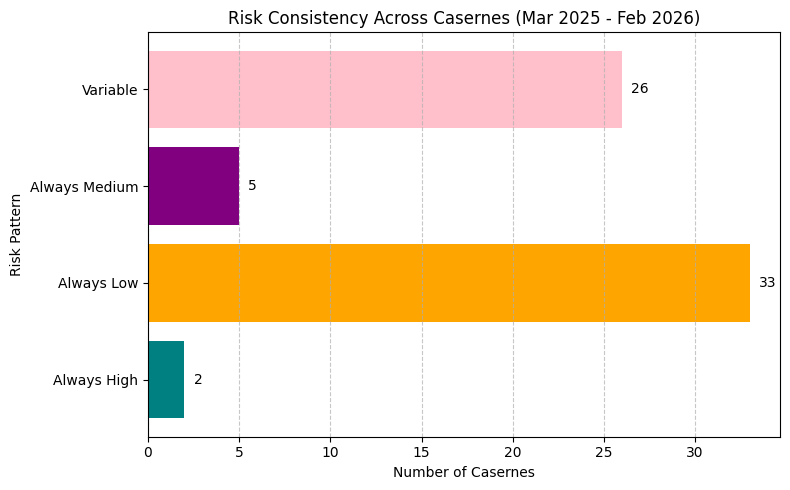

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from google.cloud import storage

# Set up GCP credentials
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = '/content/peppy-web-437616-r6-ec3f12e7c15e.json'

# Initialize the GCP storage client
storage_client = storage.Client()
bucket_name = 'ycbs299'
bucket = storage_client.get_bucket(bucket_name)

# Download the file from the GCP bucket
blob = bucket.blob('fire_risk_predictions_2025_2026.csv')
blob.download_to_filename('fire_risk_predictions_2025_2026.csv')

# Load the data
data = pd.read_csv('fire_risk_predictions_2025_2026.csv')

# Convert DATE to datetime
data['DATE'] = pd.to_datetime(data['DATE'])

# Filter data for the period March 2025 to February 2026
data = data[(data['DATE'] >= '2025-03-01') & (data['DATE'] <= '2026-02-01')]

# Group by CASERNE and check the risk pattern
def classify_risk_pattern(group):
    risks = group['PREDICTED_RISK'].unique()
    if len(risks) == 1:  # If only one unique risk value
        if risks[0] == 'High':
            return 'Always High'
        elif risks[0] == 'Low':
            return 'Always Low'
        elif risks[0] == 'Medium':
            return 'Always Medium'
    return 'Variable'  # If more than one unique risk value

# Apply classification to each CASERNE, with include_groups=False to suppress the warning
risk_patterns = data.groupby('CASERNE').apply(classify_risk_pattern, include_groups=False).reset_index(name='Risk Pattern')

# Count the number of CASERNE in each category
pattern_counts = risk_patterns['Risk Pattern'].value_counts()

# Ensure all categories are present, even if their count is 0
categories = ['Always High', 'Always Low', 'Always Medium', 'Variable']
counts = {cat: pattern_counts.get(cat, 0) for cat in categories}

# Plot the horizontal bar chart
plt.figure(figsize=(8, 5))
bars = plt.barh(list(counts.keys()), list(counts.values()), color=['teal', 'orange', 'purple', 'pink'])

# Add labels on the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{int(width)}',
             ha='left', va='center')

# Customize the plot
plt.xlabel('Number of Casernes')
plt.ylabel('Risk Pattern')
plt.title('Risk Consistency Across Casernes (Mar 2025 - Feb 2026)')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()

In [7]:
# Install required packages
!pip install xgboost

# Import libraries
import os
import pandas as pd
import numpy as np
from google.cloud import storage
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

# Set up Google Cloud credentials
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = '/content/peppy-web-437616-r6-ec3f12e7c15e.json'

# Function to download file from GCS
def download_blob(bucket_name, source_blob_name, destination_file_name):
    storage_client = storage.Client()
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(source_blob_name)
    blob.download_to_filename(destination_file_name)
    print(f"Downloaded {source_blob_name} to {destination_file_name}")

# Function to upload file to GCS
def upload_blob(bucket_name, source_file_name, destination_blob_name):
    storage_client = storage.Client()
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(destination_blob_name)
    blob.upload_from_filename(source_file_name)
    print(f"Uploaded {source_file_name} to {destination_blob_name}")

# Download the data from GCS
bucket_name = 'ycbs299'
blob_name = 'master_merged_adjusted_updated.csv'
local_file = '/content/master_merged_adjusted_updated.csv'
download_blob(bucket_name, blob_name, local_file)

# Load and process data
df = pd.read_csv(local_file).dropna()
df['DATE'] = pd.to_datetime(df[['YEAR', 'MONTH']].assign(DAY=1))
df = df.sort_values(['CASERNE', 'DATE'])

# Define features (your original 10)
features = ['MONTH_SIN', 'MONTH_COS', 'LAG1_INCIDENT_COUNT', 'TEMPERATURE_MAX',
            'CRIME_COUNT', 'TOTAL_BUILDING_AREA', 'TOTAL_BUILDINGS',
            'RESIDENTIAL', 'PUBLIC_SERVICES', 'AVG_FLOORS']
X = df[features]

# Encode the target variable
print("\n=== XGBoost Classification (UPDATED_RISK_LEVEL) ===")
le = LabelEncoder()
y_class = le.fit_transform(df['UPDATED_RISK_LEVEL'])

# Split the data chronologically to achieve a 20% test set using the most recent years
# Test set: Most recent 20% of the data (approximately 48 months, from 2021-01 to 2024-12)
# Training set: Remaining 80% (from 2005-02 to 2020-12)
test_start_date = pd.to_datetime('2022-01-01')  # Start of the test set (most recent 20%)
train_mask = df['DATE'] < test_start_date
test_mask = df['DATE'] >= test_start_date

X_train = X[train_mask]
y_train = y_class[train_mask]
X_test = X[test_mask]
y_test = y_class[test_mask]

# Verify the split
total_records = len(df)
train_size = len(X_train)
test_size = len(X_test)
print(f"Total records: {total_records}")
print(f"Training data range: {df['DATE'][train_mask].min()} to {df['DATE'][train_mask].max()}")
print(f"Test data range: {df['DATE'][test_mask].min()} to {df['DATE'][test_mask].max()}")
print(f"Training set size: {train_size} ({train_size/total_records*100:.2f}% of total)")
print(f"Test set size: {test_size} ({test_size/total_records*100:.2f}% of total)")

# XGBoost Classification with Cross-Validation and GridSearchCV on training data
kf = KFold(n_splits=5, shuffle=True, random_state=42)
xgb_clf_param_grid = {
    'max_depth': [3, 6],
    'learning_rate': [0.1, 0.01],
    'n_estimators': [100, 200]
}
xgb_clf_base = xgb.XGBClassifier(objective='multi:softmax', num_class=3, eval_metric='mlogloss', random_state=42)
xgb_clf = GridSearchCV(xgb_clf_base, xgb_clf_param_grid, cv=kf, scoring='accuracy', n_jobs=-1)
xgb_clf.fit(X_train, y_train)

print(f"Best Parameters: {xgb_clf.best_params_}")
print(f"Best Cross-Validated Accuracy: {xgb_clf.best_score_:.3f}")
print("CV Results (mean_test_score):", pd.DataFrame(xgb_clf.cv_results_)['mean_test_score'].tolist())

print("Feature Importance:")
for feature, importance in zip(features, xgb_clf.best_estimator_.feature_importances_):
    print(f"{feature}: {importance:.4f}")

# Evaluate on the test set (most recent 20%)
y_pred = xgb_clf.best_estimator_.predict(X_test)
y_pred_proba = xgb_clf.best_estimator_.predict_proba(X_test)

print("Classification Report (Test Set - Most Recent 20%):")
print(classification_report(y_test, y_pred, target_names=le.classes_))
auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
print(f"AUC-ROC (One-vs-Rest): {auc:.3f}")

# Download the prediction dataset (2025-2026) and generate predictions
pred_blob_name = 'fire_risk_predictions_2025_2026.csv'
pred_local_file = '/content/fire_risk_predictions_2025_2026.csv'
download_blob(bucket_name, pred_blob_name, pred_local_file)

# Load the prediction dataset
df_pred = pd.read_csv(pred_local_file)
df_pred['DATE'] = pd.to_datetime(df_pred['DATE'])
X_pred = df_pred[features]

# Add predictions to the 2025-2026 dataset
df_pred['PREDICTED_RISK'] = le.inverse_transform(xgb_clf.best_estimator_.predict(X_pred))
df_pred['PREDICTED_RISK_PROBA'] = xgb_clf.best_estimator_.predict_proba(X_pred).max(axis=1)

# Save and upload predictions
output_file = '/content/fire_risk_predictions_updated.csv'
df_pred.to_csv(output_file, index=False)
print(f"Saved predictions to {output_file}")
upload_blob(bucket_name, output_file, 'fire_risk_predictions_updated.csv')

Downloaded master_merged_adjusted_updated.csv to /content/master_merged_adjusted_updated.csv

=== XGBoost Classification (UPDATED_RISK_LEVEL) ===
Total records: 15774
Training data range: 2005-02-01 00:00:00 to 2021-12-01 00:00:00
Test data range: 2022-01-01 00:00:00 to 2024-12-01 00:00:00
Training set size: 13398 (84.94% of total)
Test set size: 2376 (15.06% of total)
Best Parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}
Best Cross-Validated Accuracy: 0.680
CV Results (mean_test_score): [0.6771907539569788, 0.6802510125743064, 0.6804745310402078, 0.6774139660042453, 0.6506196063356231, 0.6594268857281343, 0.6669652576980718, 0.6726379023137392]
Feature Importance:
MONTH_SIN: 0.0596
MONTH_COS: 0.1091
LAG1_INCIDENT_COUNT: 0.3090
TEMPERATURE_MAX: 0.0679
CRIME_COUNT: 0.1994
TOTAL_BUILDING_AREA: 0.0413
TOTAL_BUILDINGS: 0.0426
RESIDENTIAL: 0.0602
PUBLIC_SERVICES: 0.0696
AVG_FLOORS: 0.0414
Classification Report (Test Set - Most Recent 20%):
              precision    r

<ipython-input-8-2e85eb2b507c>:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(param_combinations, rotation=45, ha='right')


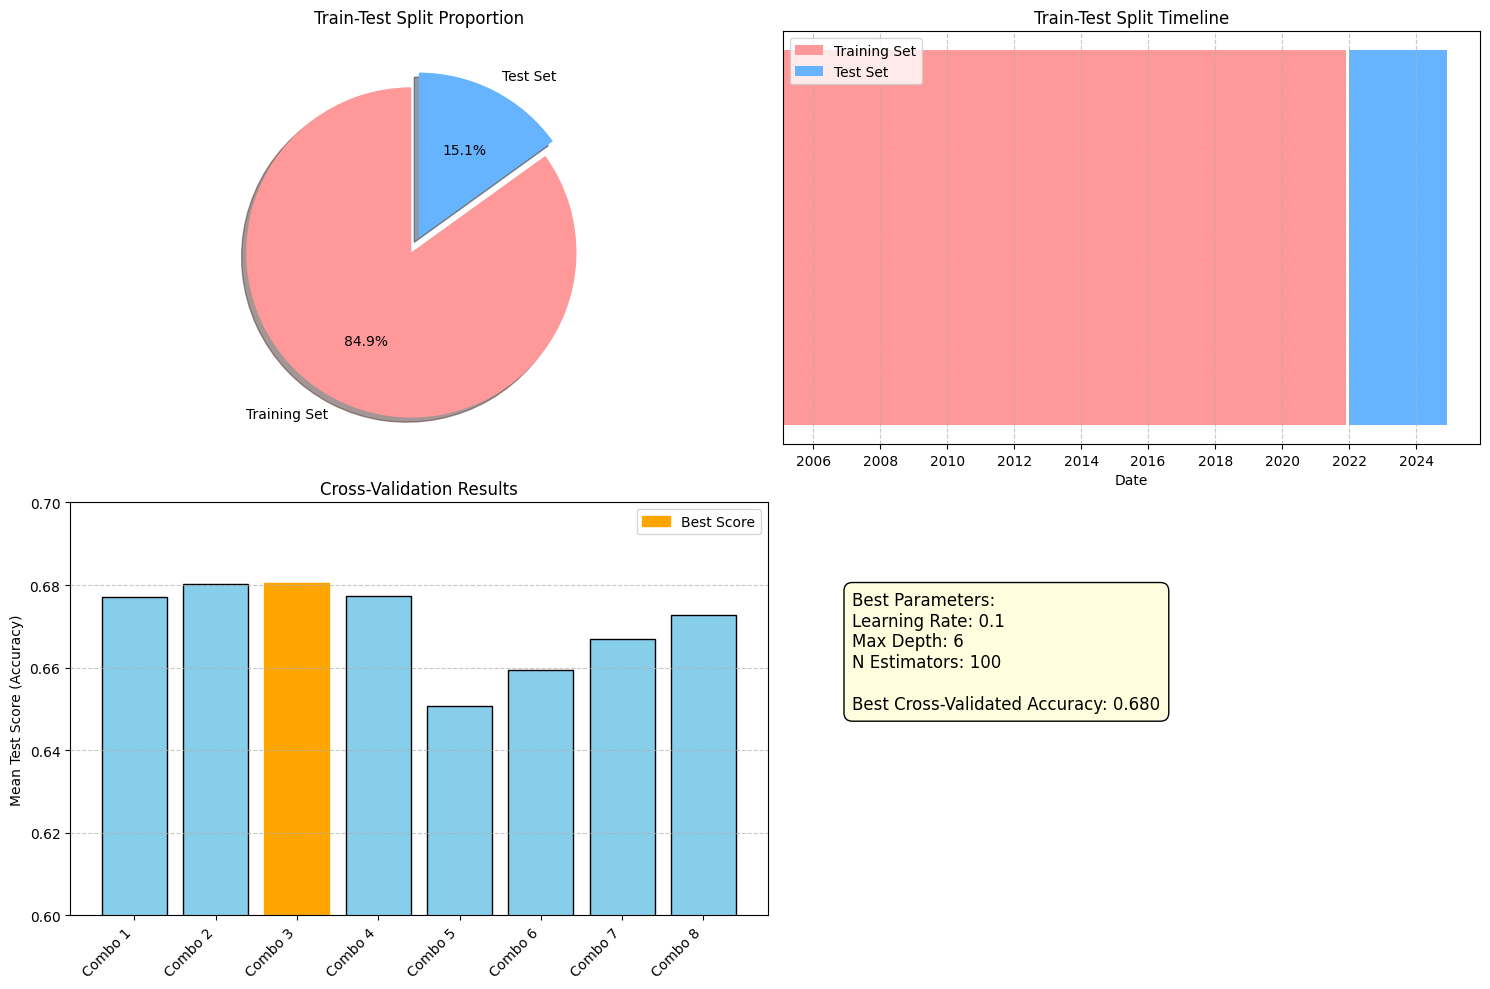

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime

# Data from the output
total_records = 15774
train_size = 13398
test_size = 2376
train_percentage = (train_size / total_records) * 100
test_percentage = (test_size / total_records) * 100
train_start = "2005-02-01"
train_end = "2021-12-01"
test_start = "2022-01-01"
test_end = "2024-12-01"
best_params = {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}
best_cv_accuracy = 0.680
cv_results = [0.6771907539569788, 0.6802510125743064, 0.6804745310402078, 0.6774139660042453,
              0.6506196063356231, 0.6594268857281343, 0.6669652576980718, 0.6726379023137392]

# Create a figure with subplots
fig = plt.figure(figsize=(15, 10))

# 1. Pie Chart for Train-Test Split
ax1 = plt.subplot(2, 2, 1)
labels = ['Training Set', 'Test Set']
sizes = [train_percentage, test_percentage]
colors = ['#ff9999', '#66b3ff']
explode = (0.1, 0)  # Explode the training set slice
ax1.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=90)
ax1.set_title('Train-Test Split Proportion')

# 2. Timeline for Train-Test Split
ax2 = plt.subplot(2, 2, 2)
train_start_dt = datetime.strptime(train_start, '%Y-%m-%d')
train_end_dt = datetime.strptime(train_end, '%Y-%m-%d')
test_start_dt = datetime.strptime(test_start, '%Y-%m-%d')
test_end_dt = datetime.strptime(test_end, '%Y-%m-%d')

# Plot horizontal bars for the timeline
ax2.barh(0.5, (train_end_dt - train_start_dt).days, left=train_start_dt, color='#ff9999', label='Training Set')
ax2.barh(0.5, (test_end_dt - test_start_dt).days, left=test_start_dt, color='#66b3ff', label='Test Set')

# Customize the timeline
ax2.set_yticks([])
ax2.set_xlabel('Date')
ax2.set_title('Train-Test Split Timeline')
ax2.legend()
ax2.grid(True, axis='x', linestyle='--', alpha=0.7)

# 3. Bar Plot for Cross-Validation Results
ax3 = plt.subplot(2, 2, 3)
param_combinations = [f'Combo {i+1}' for i in range(len(cv_results))]
bars = ax3.bar(param_combinations, cv_results, color='skyblue', edgecolor='black')
# Highlight the best score
best_idx = cv_results.index(max(cv_results))
bars[best_idx].set_color('orange')
bars[best_idx].set_label('Best Score')

ax3.set_ylim(0.6, 0.7)  # Adjust y-axis to focus on the range of scores
ax3.set_xticklabels(param_combinations, rotation=45, ha='right')
ax3.set_ylabel('Mean Test Score (Accuracy)')
ax3.set_title('Cross-Validation Results')
ax3.legend()
ax3.grid(True, axis='y', linestyle='--', alpha=0.7)

# 4. Text Annotation for Best Parameters and CV Accuracy
ax4 = plt.subplot(2, 2, 4)
ax4.axis('off')  # Turn off the axis
text = (f"Best Parameters:\n"
        f"Learning Rate: {best_params['learning_rate']}\n"
        f"Max Depth: {best_params['max_depth']}\n"
        f"N Estimators: {best_params['n_estimators']}\n\n"
        f"Best Cross-Validated Accuracy: {best_cv_accuracy:.3f}")
ax4.text(0.1, 0.5, text, fontsize=12, bbox=dict(facecolor='lightyellow', edgecolor='black', boxstyle='round,pad=0.5'))

# Adjust layout and display
plt.tight_layout()
plt.show()

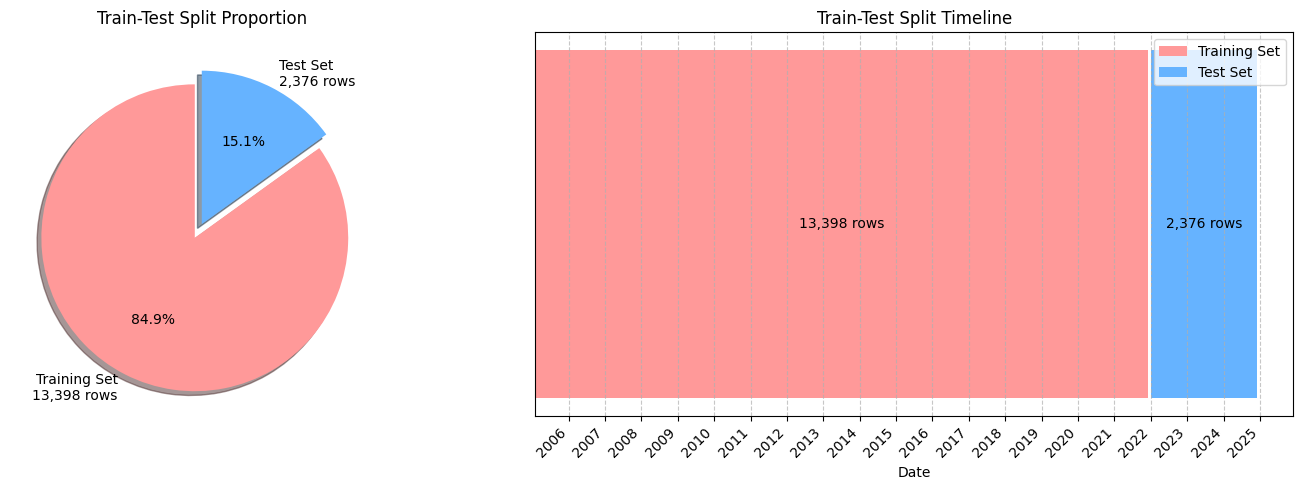

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
from datetime import datetime

# Data from the output
total_records = 15774
train_size = 13398
test_size = 2376
train_percentage = (train_size / total_records) * 100
test_percentage = (test_size / total_records) * 100
train_start = "2005-02-01"
train_end = "2021-12-01"
test_start = "2022-01-01"
test_end = "2024-12-01"

# Create a figure with subplots
fig = plt.figure(figsize=(15, 5))

# 1. Pie Chart for Train-Test Split with Row Counts
ax1 = plt.subplot(1, 2, 1)
labels = [f'Training Set\n{train_size:,} rows', f'Test Set\n{test_size:,} rows']
sizes = [train_percentage, test_percentage]
colors = ['#ff9999', '#66b3ff']
explode = (0.1, 0)  # Explode the training set slice
ax1.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=90)
ax1.set_title('Train-Test Split Proportion')

# 2. Timeline for Train-Test Split with Row Counts
ax2 = plt.subplot(1, 2, 2)
train_start_dt = pd.to_datetime(train_start)
train_end_dt = pd.to_datetime(train_end)
test_start_dt = pd.to_datetime(test_start)
test_end_dt = pd.to_datetime(test_end)

# Convert dates to Matplotlib's internal date format
train_start_num = mdates.date2num(train_start_dt)
train_end_num = mdates.date2num(train_end_dt)
test_start_num = mdates.date2num(test_start_dt)
test_end_num = mdates.date2num(test_end_dt)

# Plot horizontal bars for the timeline with adjusted height
bar_height = 0.3
ax2.barh(0.5, train_end_num - train_start_num, height=bar_height, left=train_start_num, color='#ff9999', label='Training Set')
ax2.barh(0.5, test_end_num - test_start_num, height=bar_height, left=test_start_num, color='#66b3ff', label='Test Set')

# Add row counts inside the bars
train_midpoint = train_start_num + (train_end_num - train_start_num) / 2
test_midpoint = test_start_num + (test_end_num - test_start_num) / 2
ax2.text(train_midpoint, 0.5, f'{train_size:,} rows', ha='center', va='center', fontsize=10, color='black')
ax2.text(test_midpoint, 0.5, f'{test_size:,} rows', ha='center', va='center', fontsize=10, color='black')

# Customize the timeline
ax2.set_yticks([])
ax2.set_xlabel('Date')
ax2.set_title('Train-Test Split Timeline')
ax2.legend()

# Format the x-axis with dates
ax2.xaxis_date()
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.grid(True, axis='x', linestyle='--', alpha=0.7)

# Rotate x-axis labels for better readability
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')

# Adjust layout and display
plt.tight_layout()
plt.show()